In [14]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns


# Paths

# Paths
PROJECT_ROOT = Path('../../01_data/3_analysis/price_adders_analysis/post_202512').resolve()
PRICE_ADDERS = PROJECT_ROOT / 'post_202512_price_adders_hourly.csv'
PRICE_SPIKE = PROJECT_ROOT / 'rtm_price_mean_20251205_20260516.csv'
OUT_DIR = PROJECT_ROOT

In [15]:
df_adders_numerical = pd.read_csv(PRICE_ADDERS)
df_adders_numerical

,date,RTRDPA,RTRDPRU,RTRDPRD,RTRDPRRS,RTRDPECRS,RTRDPNS
0,2025-12-05 00:00:00,0.0,0.2575,1.4625,0.2625,0.4700,1.7325
1,2025-12-05 01:00:00,0.0,0.5325,0.6200,0.0550,0.0850,0.8125
2,2025-12-05 02:00:00,0.0,0.1650,0.3575,0.0300,0.0575,0.5150
3,2025-12-05 03:00:00,0.0,0.2425,0.0175,0.0000,0.0000,0.2525
4,2025-12-05 04:00:00,0.0,0.5800,0.5825,0.0100,0.0100,0.4850
...,...,...,...,...,...,...,...
3906,2026-05-16 19:00:00,0.0,0.2600,0.5675,0.0100,0.0225,0.1000
3907,2026-05-16 20:00:00,0.0,0.1575,0.5275,0.0700,0.1450,0.5675
3908,2026-05-16 21:00:00,0.0,0.4725,1.3400,0.6000,1.2450,4.9750
3909,2026-05-16 22:00:00,0.0,0.1775,0.7800,0.1325,0.2575,1.0425


In [16]:
# add new columns to ADDER_COLS to include them everywhere below
ADDER_COLS = ['RTRDPA', 'RTRDPRU', 'RTRDPRD', 'RTRDPRRS', 'RTRDPECRS', 'RTRDPNS']

df_adders_numerical['date'] = pd.to_datetime(df_adders_numerical['date'])
df_adders_numerical['adder_sum'] = df_adders_numerical[ADDER_COLS].sum(axis=1)
df_adders_numerical

,date,RTRDPA,RTRDPRU,RTRDPRD,RTRDPRRS,RTRDPECRS,RTRDPNS,adder_sum
0,2025-12-05 00:00:00,0.0,0.2575,1.4625,0.2625,0.4700,1.7325,4.1850
1,2025-12-05 01:00:00,0.0,0.5325,0.6200,0.0550,0.0850,0.8125,2.1050
2,2025-12-05 02:00:00,0.0,0.1650,0.3575,0.0300,0.0575,0.5150,1.1250
3,2025-12-05 03:00:00,0.0,0.2425,0.0175,0.0000,0.0000,0.2525,0.5125
4,2025-12-05 04:00:00,0.0,0.5800,0.5825,0.0100,0.0100,0.4850,1.6675
...,...,...,...,...,...,...,...,...
3906,2026-05-16 19:00:00,0.0,0.2600,0.5675,0.0100,0.0225,0.1000,0.9600
3907,2026-05-16 20:00:00,0.0,0.1575,0.5275,0.0700,0.1450,0.5675,1.4675
3908,2026-05-16 21:00:00,0.0,0.4725,1.3400,0.6000,1.2450,4.9750,8.6325
3909,2026-05-16 22:00:00,0.0,0.1775,0.7800,0.1325,0.2575,1.0425,2.3900


In [17]:
# exclude 0 values
print(f'total rows: {len(df_adders_numerical)}')
for col in df_adders_numerical.columns[1:]:
    non_zero_count = (df_adders_numerical[col] != 0).sum()
    print(f"{col}: {non_zero_count} non-zero values")

total rows: 3911
RTRDPA: 615 non-zero values
RTRDPRU: 3590 non-zero values
RTRDPRD: 3794 non-zero values
RTRDPRRS: 3741 non-zero values
RTRDPECRS: 3760 non-zero values
RTRDPNS: 3911 non-zero values
adder_sum: 3911 non-zero values


In [18]:
# set 0-1 values to 0 for better visualization
for col in df_adders_numerical.columns[1:]:
    df_adders_numerical[col] = df_adders_numerical[col].apply(lambda x: 0 if x < 1 else x)

/var/folders/0q/ndh_pk0s37n95y6svtjfy7hw0000gp/T/ipykernel_48837/1958256763.py:32: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


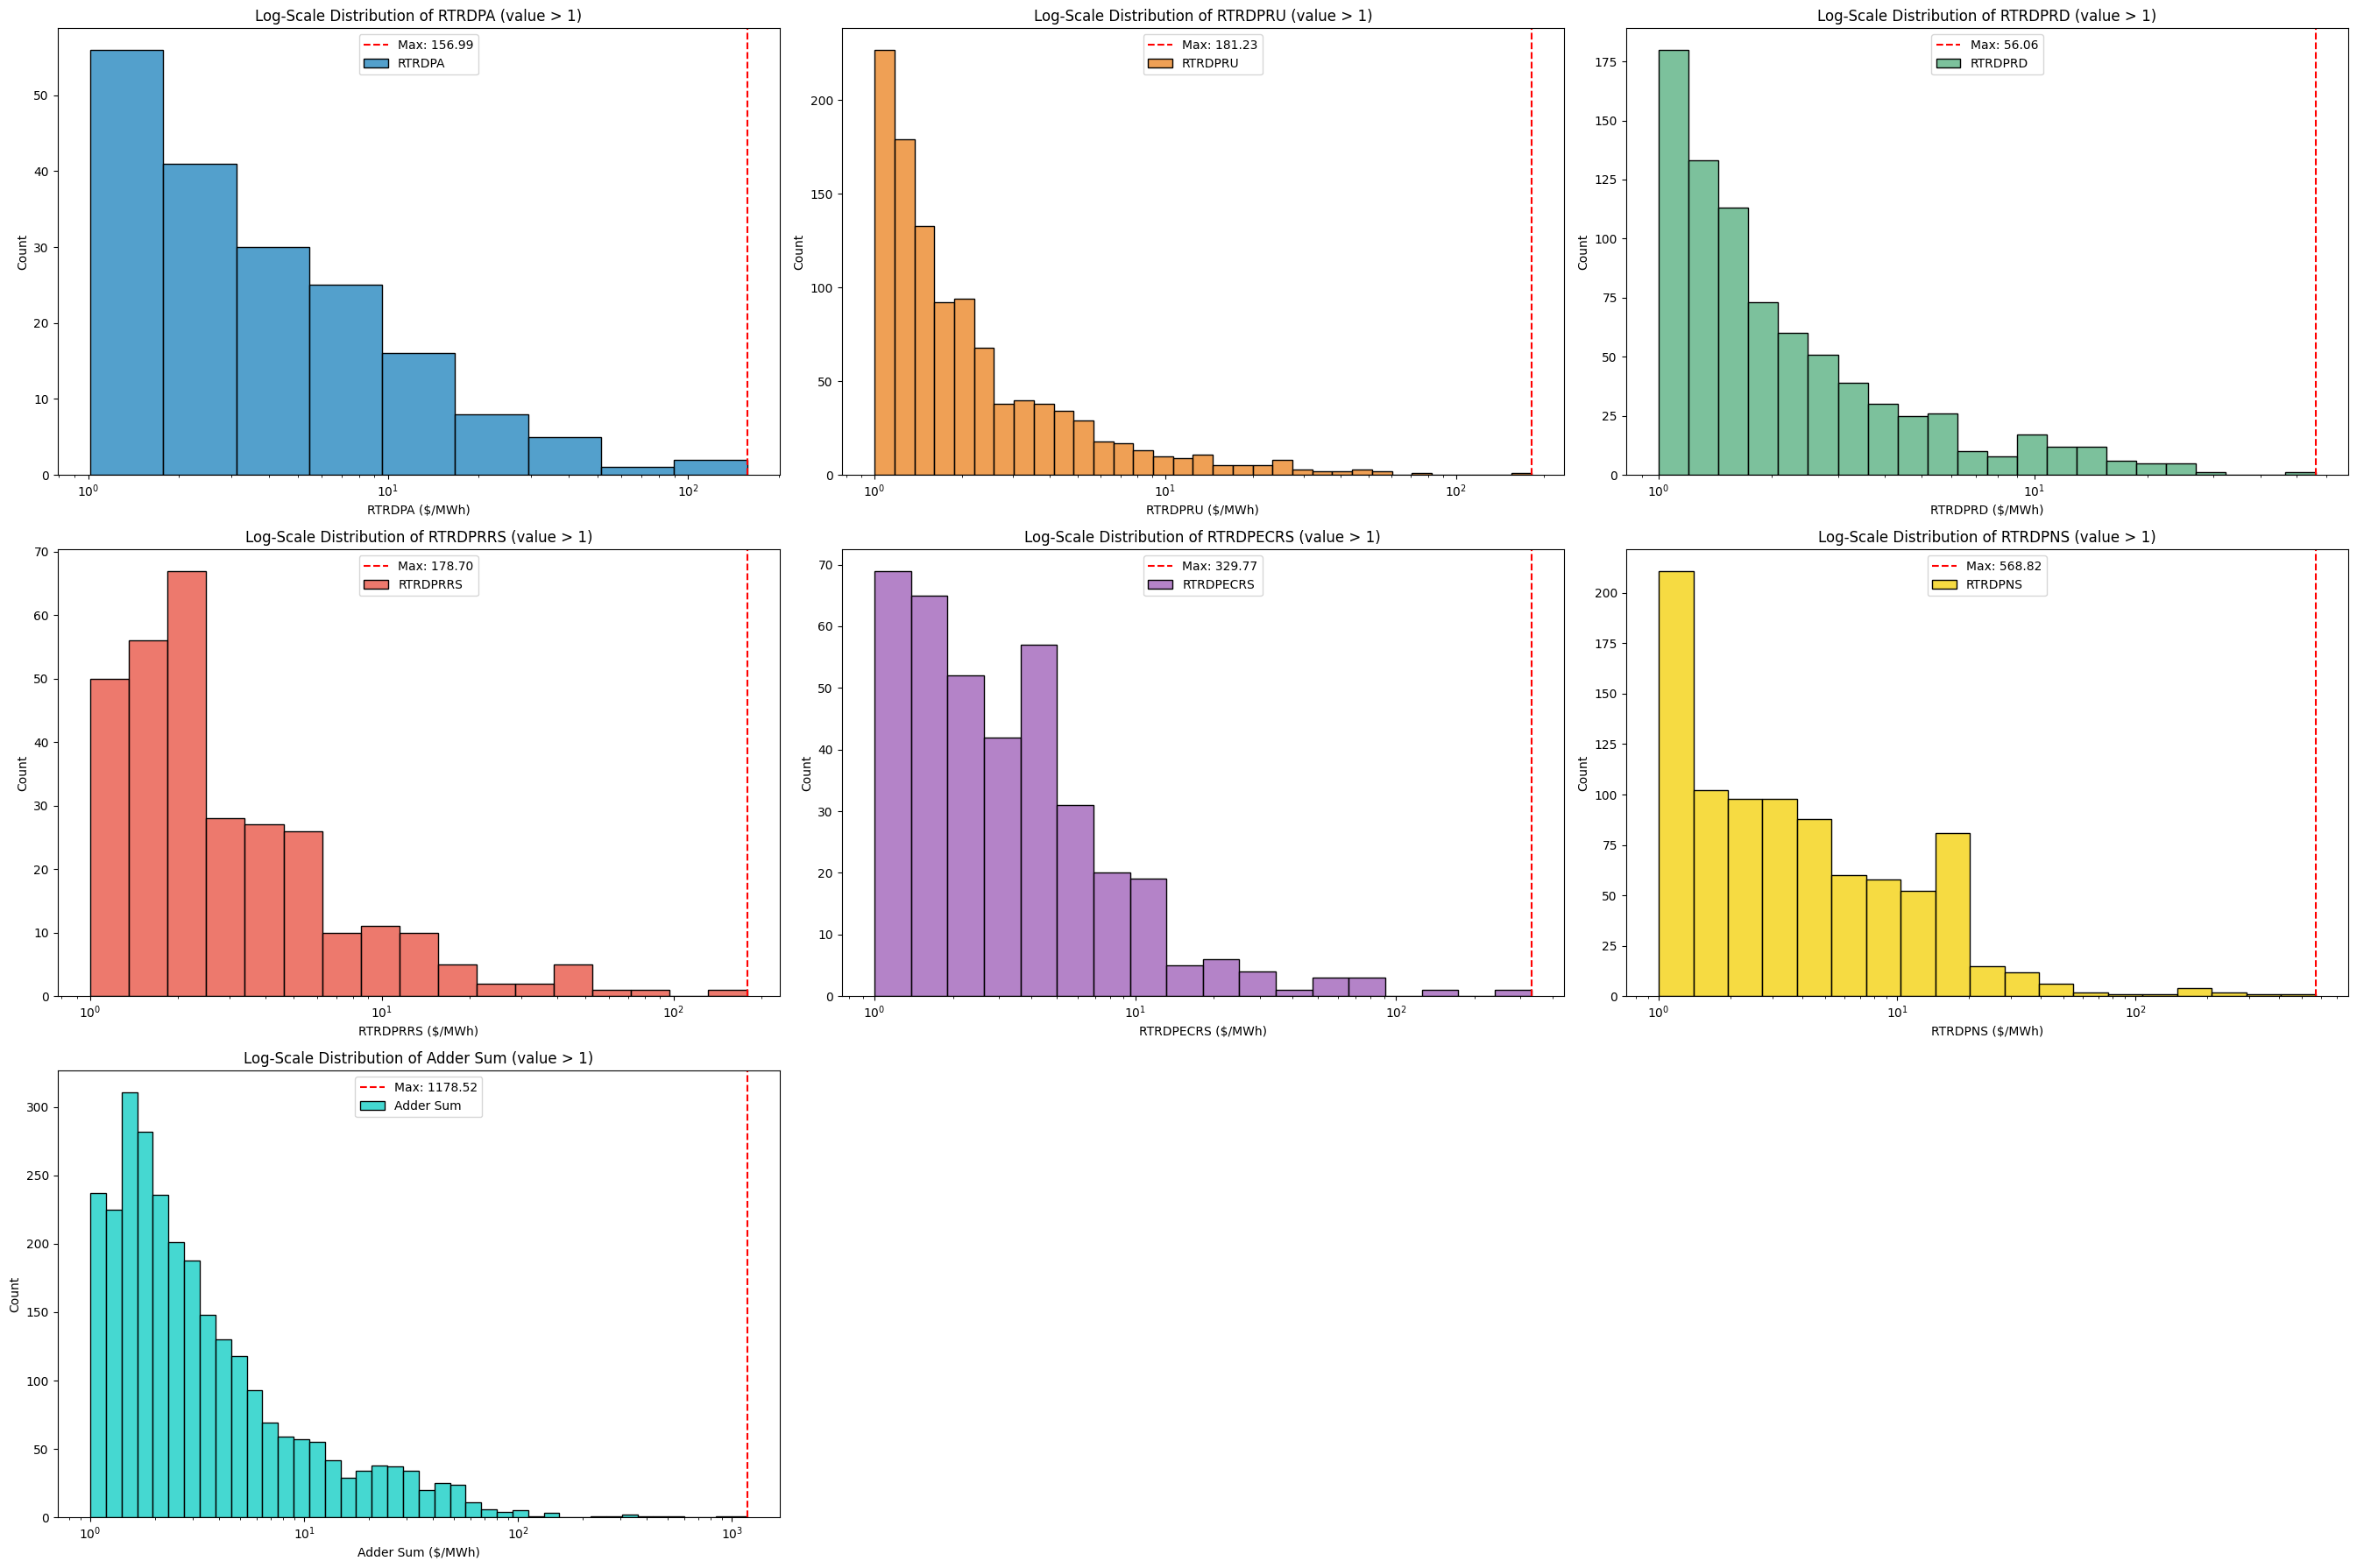

In [35]:
# pdf for price adders — grid auto-sizes; add columns to ADDER_COLS above to include them here
PLOT_COLS = ADDER_COLS + ['adder_sum']
LABELS = {col: col for col in ADDER_COLS}
LABELS['adder_sum'] = 'Adder Sum'
colors = ["#1a80bb", '#ea801c', "#50ad7b", "#e74c3c", "#9b59b6", "#f3cf02", "#06ccc2"]

ncols = 3
nrows = (len(PLOT_COLS) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(9 * ncols, 6 * nrows))
axes_flat = axes.flatten()

for i, col in enumerate(PLOT_COLS):
    ax = axes_flat[i]
    label = LABELS[col]
    vals = df_adders_numerical[col]
    sns.histplot(vals, label=label, log_scale=True, color=colors[i % len(colors)], ax=ax)
    max_val = vals.max()
    ax.axvline(max_val, color='red', linestyle='--', label=f'Max: {max_val:.2f}')
    ax.legend()
    #ax.set_xlim(1, 1200)
    #ax.set_ylim(0, 250)
    ax.set_title(f'Log-Scale Distribution of {label} (value > 1)')
    ax.set_xscale('log')
    ax.set_xlabel(f'{label} ($/MWh)')
    ax.set_ylabel('Count')

for ax in axes_flat[len(PLOT_COLS):]:
    ax.set_visible(False)

fig.tight_layout()
fig.savefig(OUT_DIR / 'price_adders_pdf.png', dpi=300)
fig.show()

In [32]:
df_adders_numerical.iloc[:, 1:].describe()

,RTRDPA,RTRDPRU,RTRDPRD,RTRDPRRS,RTRDPECRS,RTRDPNS,adder_sum
count,3911.000000,3911.000000,3911.000000,3911.000000,3911.000000,3911.000000,3911.000000
mean,0.356589,0.968791,0.638016,0.428150,0.629052,1.954926,5.737573
std,3.978557,4.463742,2.248294,3.952139,6.647883,14.358950,31.237521
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.657500
75%,0.000000,1.080000,0.000000,0.000000,0.000000,0.000000,3.537500
max,156.990000,181.230000,56.057500,178.702500,329.770000,568.817500,1178.517500
